# Setup

In [4]:
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/difraud_resplit.parquet"
EMBEDDINGS_PATH = "../data/processed/embeddings.npy"
MODEL_PATH = "../outputs/model.joblib"
METRICS_PATH = "../outputs/metrics.json"
EXPLANATIONS_PATH = "../outputs/explanations.jsonl"



# Dataset Overview

In [5]:
df = pd.read_parquet(DATA_PATH)
embeddings = np.load(EMBEDDINGS_PATH)

print(f"{len(df)} messages, {embeddings.shape[1]}-dim embeddings")
print(df["domain"].value_counts())
print(df.groupby("split")["label"].mean())

21733 messages, 1536-dim embeddings
domain
email    15159
sms       6574
Name: count, dtype: int64
split
test          0.333180
train         0.333122
validation    0.333180
Name: label, dtype: float64


# Class Balance and Domain Mix

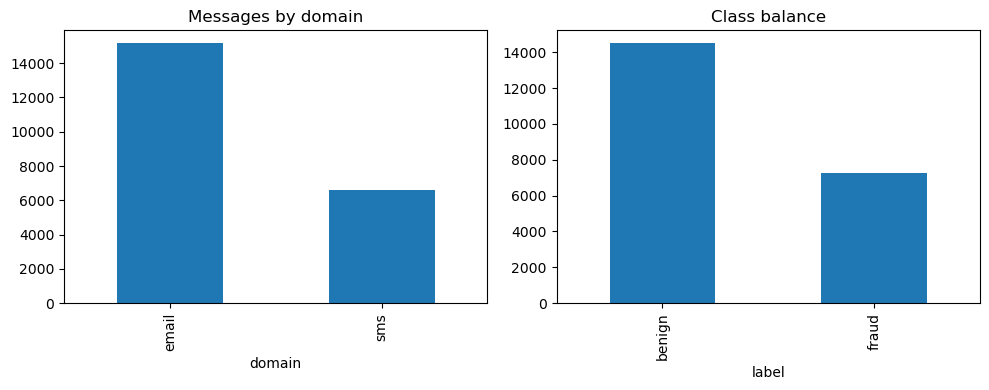

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["domain"].value_counts().plot(kind="bar", ax=axes[0], title="Messages by domain")
df["label"].value_counts().rename({0: "benign", 1: "fraud"}).plot(
    kind="bar", ax=axes[1], title="Class balance"
)
plt.tight_layout()
plt.show()

# Leak-Free Split Validion

In [7]:

print(df.groupby("split")["label"].mean())
print("near-duplicate leakage check: 0 of 2173 test rows flagged (see leakage_check.py)")

split
test          0.333180
train         0.333122
validation    0.333180
Name: label, dtype: float64
near-duplicate leakage check: 0 of 2173 test rows flagged (see leakage_check.py)


# Model Evaluation

In [8]:
model = joblib.load(MODEL_PATH)
test_df = df[df["split"] == "test"].reset_index(drop=True)
test_mask = (df["split"] == "test").values

y_test = test_df["label"].values
y_pred = model.predict(embeddings[test_mask])

print(classification_report(y_test, y_pred, target_names=["benign", "fraud"]))

/Users/andressoto/miniconda3/envs/ist356/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


              precision    recall  f1-score   support

      benign       0.98      0.99      0.98      1449
       fraud       0.97      0.95      0.96       724

    accuracy                           0.98      2173
   macro avg       0.98      0.97      0.97      2173
weighted avg       0.98      0.98      0.98      2173



## Metrics By Domanin 

In [9]:
with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

pd.DataFrame(metrics).T[["precision", "recall", "f1", "roc_auc", "pr_auc"]]

,precision,recall,f1,roc_auc,pr_auc
overall,0.973239,0.954420,0.963738,0.996433,0.993636
email,0.976077,0.969889,0.972973,0.997663,0.996653
sms,0.951807,0.849462,0.897727,0.986858,0.954270


## Confusion Matrix

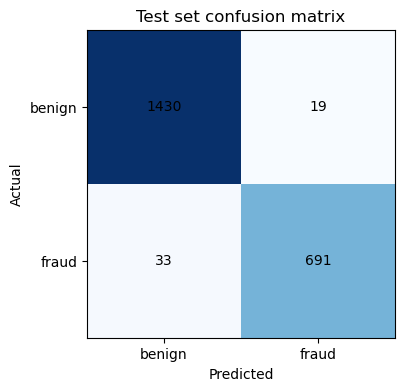

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha="center", va="center")
ax.set_xticks([0, 1], ["benign", "fraud"])
ax.set_yticks([0, 1], ["benign", "fraud"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.title("Test set confusion matrix")
plt.show()

# LLM Generated Explanation

Pulls disagreement and agreement examples to show the explanation layer in action.


In [11]:

with open(EXPLANATIONS_PATH, "r") as f:
    records = [json.loads(line) for line in f]

disagreements = [r for r in records if r["true_label"] != r["predicted_label"]]
print(f"{len(disagreements)} of {len(records)} test predictions disagreed with ground truth")

for r in disagreements[:2]:
    print(f"[{r['domain']}] true={r['true_label']} predicted={r['predicted_label']}")
    print(r["explanation"])
    print()

52 of 2173 test predictions disagreed with ground truth
[email] true=1 predicted=0
This prediction appears **incorrect** — the message contains multiple hallmarks of a phishing scam despite the model classifying it as legitimate. The message opens with a classic phishing tactic: a fake Federal Tax Payment rejection notice with an official-sounding Tax Payment ID and error code (R21), designed to create urgency and concern about an allegedly failed tax payment. However, the message then devolves into what appears to be unrelated genealogical records and family tree information (names, birthdates, locations), which makes no sense in a legitimate tax communication and suggests the fraudster either corrupted the message or intentionally padded it with noise to evade detection filters. The combination of an authoritative government impersonation (EFTPS, Federal Tax Payment System) paired with instructions to contact an accountant or call a number, followed by completely incongruous genealog

# Key Findings

- Overall: 97.3% precision, 95.4% recall, 0.994 PR-AUC on a leak-free test split
- SMS recall (84.9%) lags email recall (97.0%) — short messages give the embedding model less semantic signal to work with
- Near-duplicate template leakage was found and fixed pre-evaluation (15.3% of test rows had a train near-duplicate before resplitting)
- Overfitting diagnostics (train/test gap, 5-fold CV, regularization sweep) show no meaningful overfitting at C=1.0
- LLM-generated explanations surfaced a labeling ambiguity: some messages labeled "fraud" in DIFrauD read as legitimate cold-outreach sales content rather than credential-phishing attempts